# Population-model training analysis

Reads the output of `ProVoice.training_scripts.run_population_pipeline` — four sweeps,
each in its own directory:

| section | stage | loss | window | grid |
|---|---|---|---|---|
| 1 | `corn_w10` | soft-CORN | 10 s | full (3 dropout x 2 lr) |
| 2 | `ce_w10`   | softmax/CE | 10 s | full |
| 3 | `corn_w5`  | soft-CORN | 5 s  | winner of stage 1 |
| 4 | `corn_w20` | soft-CORN | 20 s | winner of stage 1 |

Every section produces the same eight things, so the stages stay comparable:

1. **Per-configuration** table — set-MAE / set-accuracy averaged over folds and seeds.
2. **Per-configuration x validation-fold** table — the same, broken out by fold.
3. **Early-win table** — how often an epoch below `--min-select-epoch` would have won.
4. **Init vs best vs constant** — does training achieve anything, and does it beat a constant?
5. **Variance decomposition** — can this sweep resolve configurations at all?
6. **Paired configuration comparison** — config deltas with fold difficulty cancelled.
7. **Distribution-distance tables** — earth-mover's distance between the prediction,
   train-label and validation-label shapes over LoA: per configuration x fold (7),
   then averaged over every run in the stage (7b).
8. **Histograms and validation curves.**

Stages with a single configuration (3 and 4) use the identical format, just with one row.

**Two reference lines recur and both matter:**

* the **constant floor** — best set-MAE reachable by always predicting one fixed LoA
  (~1.32 globally on this cohort). A model above it is losing to "always say 1".
* the **untrained init** — the model before a single gradient step. Beating *this* is
  "training did something"; beating the *floor* is "what it did generalizes". Those are
  different claims and the tables below keep them apart.

In [1]:
import sys, pathlib, warnings, itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance
from scipy.spatial.distance import jensenshannon
from IPython.display import display, Markdown

# The notebook lives in src/ProVoice/training_analysis/; walk up to find src/.
_SRC = pathlib.Path.cwd()
for _ in range(6):
    if (_SRC / "ProVoice").is_dir():
        break
    _SRC = _SRC.parent
sys.path.insert(0, str(_SRC))

# Imported, not re-implemented: anything recomputed from the curves must use the
# SAME smoothing the sweep used, or it answers a different question.
from ProVoice.training_scripts.sweep_population_hparams import smooth, SMOOTH_WINDOW

%matplotlib inline
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)
warnings.filterwarnings("ignore", category=FutureWarning)

# ---------------------------------------------------------------- configuration
BASE = pathlib.Path("../../../results/pop_pipeline")   # the pipeline's --outdir
MIN_SELECT_EPOCH = 3      # must match the value the sweep ran with
LOA = [0, 1, 2, 3, 4]

STAGES = [
    ("corn_w10", "1. Full grid — soft-CORN, 10 s window"),
    ("ce_w10",   "2. Softmax / cross-entropy ablation — 10 s window"),
    ("corn_w5",  "3. 5 s window — soft-CORN, winning configuration"),
    ("corn_w20", "4. 20 s window — soft-CORN, winning configuration"),
]
print(f"BASE = {BASE.resolve()}")
for name, _ in STAGES:
    p = BASE / name / "sweep_results.csv"
    n = (sum(1 for _ in p.open()) - 1) if p.exists() else 0
    print(f"  {name:<10} {'found' if p.exists() else 'MISSING':<8} {n:>4} rows")

BASE = C:\DATA\UCL\Asignaturas\TFM\MarkColley_Mercedes\ProActivity_Personalization\results\pop_pipeline
  corn_w10   MISSING     0 rows
  ce_w10     MISSING     0 rows
  corn_w5    MISSING     0 rows
  corn_w20   MISSING     0 rows


In [2]:
# ------------------------------------------------------------------- loading

def load_stage(name: str) -> pd.DataFrame:
    """One stage's sweep_results.csv, or an empty frame if it has not run."""
    p = BASE / name / "sweep_results.csv"
    if not p.exists():
        return pd.DataFrame()
    df = pd.read_csv(p)
    # window/loss are constant within a stage, so the configuration IS (dropout, lr).
    df["config"] = ("drop=" + df["dropout"].astype(str)
                    + " lr=" + df["lr"].map(lambda x: f"{x:g}"))
    return df


def load_curves(name: str) -> pd.DataFrame:
    """Every per-epoch curve for a stage, tagged by its filename."""
    d = BASE / name / "runs"
    if not d.exists():
        return pd.DataFrame()
    out = []
    for f in sorted(d.glob("metrics_*.csv")):
        try:
            c = pd.read_csv(f)
        except Exception:
            continue
        if c.empty:
            continue
        c["tag"] = f.stem[len("metrics_"):]
        out.append(c)
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()


def _config_from_tag(tag: str):
    """(config label, dropout, lr, fold) from a run tag `d0.15_lr0.002_f001-005_s0_w10_corn`."""
    try:
        drop = float(tag.split("_lr")[0][1:])
        rest = tag.split("_lr")[1]
        lr = float(rest.split("_f")[0])
        fold = rest.split("_f")[1].split("_s")[0].replace("-", "|")
        return f"drop={drop} lr={lr:g}", drop, lr, fold
    except Exception:
        return "?", np.nan, np.nan, "?"


def per_run_curves(name: str, min_select_epoch: int = MIN_SELECT_EPOCH) -> pd.DataFrame:
    """One row per RUN, derived from its retained per-epoch curve.

    The shared source for the early-win and init-vs-best tables — both need the
    curve, not the summary CSV, because the summary only records the FLOORED
    selection and never records the untrained init.
    """
    curves = load_curves(name)
    if curves.empty:
        return pd.DataFrame()
    rows = []
    for tag, c in curves.groupby("tag"):
        c = c.sort_values("epoch")
        mae = c["set_mae"].to_numpy(dtype=float)
        if len(mae) == 0:
            continue
        sm = smooth(mae, SMOOTH_WINDOW)
        j_free = int(np.argmin(sm))                        # no floor
        lo = min(int(min_select_epoch), len(sm) - 1)
        j_sel = lo + int(np.argmin(sm[lo:]))               # as the sweep selects
        cfg, drop, lr, fold = _config_from_tag(tag)

        def col(nm, default=np.nan):
            return float(c[nm].iloc[0]) if nm in c.columns and pd.notna(c[nm].iloc[0]) else default

        rows.append({
            "tag": tag, "config": cfg, "dropout": drop, "lr": lr, "val_pids": fold,
            "epochs_run": len(mae),
            "epoch_unfloored": int(c["epoch"].iloc[j_free]),
            "epoch_selected": int(c["epoch"].iloc[j_sel]),
            "mae_unfloored": float(sm[j_free]),
            "mae_selected": float(sm[j_sel]),
            "acc_selected": float(c["set_acc"].iloc[j_sel]),
            "init_mae": col("init_set_mae"), "init_acc": col("init_set_acc"),
            "const_mae": col("const_set_mae"), "const_acc": col("const_set_acc"),
        })
    return pd.DataFrame(rows)


def _fmt(df: pd.DataFrame, cols) -> pd.DataFrame:
    df = df.copy()
    for c in cols:
        if c in df:
            df[c] = df[c].astype(float).round(3)
    return df

In [3]:
# ---------------------------------------------------------- tables 1 and 2

def table_per_config(df: pd.DataFrame) -> pd.DataFrame:
    """set-MAE / set-accuracy per configuration, averaged over folds and seeds.

    `set_mae` is `smoothed_best_set_mae` — what the sweep RANKS on — not the raw
    per-epoch minimum, which is optimistically biased by minimising over ~100
    noisy epochs. `mae_raw` keeps that minimum alongside so the gap is visible.

    `vs_const` is the number to read: negative beats a constant prediction,
    positive does not.
    """
    if df.empty:
        return pd.DataFrame()
    g = df.groupby("config", as_index=False).agg(
        n_runs=("seed", "size"),
        set_mae=("smoothed_best_set_mae", "mean"),
        mae_sd=("smoothed_best_set_mae", "std"),
        mae_raw=("best_set_mae", "mean"),
        set_acc=("set_acc_at_best", "mean"),
        acc_sd=("set_acc_at_best", "std"),
        qwk=("qwk_at_best", "mean"),
        const_mae=("const_set_mae", "mean"),
        const_acc=("const_set_acc", "mean"),
        E_star=("best_epoch_1se", "median"),
    )
    g["mae_se"] = g["mae_sd"] / np.sqrt(g["n_runs"].clip(lower=1))
    g["vs_const"] = g["set_mae"] - g["const_mae"]
    g["beats_const"] = g["vs_const"] < 0
    cols = ["config", "n_runs", "set_mae", "mae_sd", "mae_se", "mae_raw",
            "set_acc", "acc_sd", "qwk", "const_mae", "const_acc",
            "vs_const", "beats_const", "E_star"]
    return _fmt(g[cols].sort_values("set_mae").reset_index(drop=True),
                ["set_mae", "mae_sd", "mae_se", "mae_raw", "set_acc", "acc_sd",
                 "qwk", "const_mae", "const_acc", "vs_const"])


def table_per_config_fold(df: pd.DataFrame) -> pd.DataFrame:
    """The same metrics broken out by configuration x validation fold.

    Where fold heterogeneity becomes visible: constant floors range ~0.54 to ~1.47
    across folds, so a configuration's mean hides which folds it actually failed on.
    """
    if df.empty:
        return pd.DataFrame()
    g = df.groupby(["config", "val_pids"], as_index=False).agg(
        n_seeds=("seed", "size"),
        set_mae=("smoothed_best_set_mae", "mean"),
        mae_sd=("smoothed_best_set_mae", "std"),
        set_acc=("set_acc_at_best", "mean"),
        acc_sd=("set_acc_at_best", "std"),
        const_mae=("const_set_mae", "mean"),
        const_acc=("const_set_acc", "mean"),
        val_n=("val_n", "mean"),
        E_star=("best_epoch_1se", "median"),
    )
    g["vs_const"] = g["set_mae"] - g["const_mae"]
    g["beats_const"] = g["vs_const"] < 0
    return _fmt(g.sort_values(["config", "val_pids"]).reset_index(drop=True),
                ["set_mae", "mae_sd", "set_acc", "acc_sd", "const_mae",
                 "const_acc", "vs_const"])

In [4]:
# ------------------------------ table 3: early wins, table 4: init vs best

def table_early_wins(pr: pd.DataFrame,
                     min_select_epoch: int = MIN_SELECT_EPOCH) -> pd.DataFrame:
    """How often an epoch BELOW the floor would have won, and what the floor cost.

    `--min-select-epoch` blocks early epochs from being checkpointed: epochs
    inside the LR warmup are not comparable to full-LR ones, and an unconstrained
    argmin of epoch 0 makes E*=0 — which would make the LODO runner train for
    zero epochs and ship random inits as population models.

    This says whether the floor is PROTECTING or BINDING:

    * `pct_early` — share of runs whose unfloored smoothed argmin was < the floor.
      High means held-out performance peaks before the model has trained, i.e.
      training hurts transfer from the start.
    * `mae_cost` — mean (selected - unfloored) over those runs: what the floor
      gave up. Compare against `mae_se` in table 1; below ~1 SE it is noise.
    """
    if pr.empty:
        return pd.DataFrame()
    pr = pr.copy()
    pr["early"] = pr["epoch_unfloored"] < min_select_epoch
    pr["cost"] = pr["mae_selected"] - pr["mae_unfloored"]
    g = pr.groupby("config", as_index=False).agg(
        n_runs=("early", "size"), n_early=("early", "sum"),
        median_epoch_unfloored=("epoch_unfloored", "median"),
        median_epoch_selected=("epoch_selected", "median"))
    cost = (pr[pr["early"]].groupby("config", as_index=False)["cost"]
            .mean().rename(columns={"cost": "mae_cost"}))
    g = g.merge(cost, on="config", how="left")
    g["pct_early"] = (100 * g["n_early"] / g["n_runs"]).round(1)
    g = g[["config", "n_runs", "n_early", "pct_early", "mae_cost",
           "median_epoch_unfloored", "median_epoch_selected"]]
    return _fmt(g.sort_values("pct_early", ascending=False).reset_index(drop=True),
                ["mae_cost"])


def table_init_vs_best(pr: pd.DataFrame) -> pd.DataFrame:
    """Untrained init -> selected model -> constant floor, per configuration.

    Separates two diagnoses the summary tables conflate:

    * `gain_vs_init` = selected - init. NEGATIVE means training achieved
      something. If it is ~0, the model learned nothing and every other number
      here is describing a random initialization.
    * `vs_const` = selected - constant floor. NEGATIVE means what it learned
      generalizes to held-out drivers.

    The interesting case on this cohort is `gain_vs_init < 0 < vs_const`:
    training works and still loses to "always predict one level", because driver
    preference does not transfer. `verdict` names which case each row is in.
    """
    if pr.empty or pr["init_mae"].isna().all():
        return pd.DataFrame()
    g = pr.groupby("config", as_index=False).agg(
        n_runs=("tag", "size"),
        init_mae=("init_mae", "mean"), init_acc=("init_acc", "mean"),
        best_mae=("mae_selected", "mean"), best_acc=("acc_selected", "mean"),
        const_mae=("const_mae", "mean"), const_acc=("const_acc", "mean"))
    g["gain_vs_init"] = g["best_mae"] - g["init_mae"]
    g["vs_const"] = g["best_mae"] - g["const_mae"]

    def verdict(r):
        learned, generalizes = r["gain_vs_init"] < -0.02, r["vs_const"] < 0
        if learned and generalizes:
            return "learns AND beats constant"
        if learned:
            return "learns, does NOT transfer"
        if generalizes:
            return "beats constant without learning (?)"
        return "no learning, no transfer"

    g["verdict"] = g.apply(verdict, axis=1)
    cols = ["config", "n_runs", "init_mae", "best_mae", "const_mae",
            "gain_vs_init", "vs_const", "init_acc", "best_acc", "const_acc", "verdict"]
    return _fmt(g[cols].sort_values("best_mae").reset_index(drop=True),
                [c for c in cols if c not in ("config", "n_runs", "verdict")])

In [5]:
# ---------------- table 5: variance decomposition, table 6: paired comparison

def table_variance(df: pd.DataFrame) -> pd.DataFrame:
    """Is this sweep able to resolve configurations at all?

    A go/no-go check, not a description. Three sources of spread in
    `smoothed_best_set_mae`:

    * **fold** — SD of the fold means. Expected to dominate: folds differ in
      intrinsic difficulty (constant floors ~0.54 to ~1.47), and that is a
      property of the drivers, not of any configuration.
    * **seed** — mean within-(config, fold) SD across seeds. The noise floor of a
      single run.
    * **config** — SD of the configuration means, and their max-min spread. This
      is the signal the sweep exists to measure.

    The verdict compares the configuration SPREAD against the standard error of
    a configuration mean (seed SD / sqrt(runs per config)). If the spread is
    below ~2 SE the ranking is not resolvable, and picking a winner is picking
    noise — in which case take the most regularized configuration (the sweep's
    own tie-break) and spend the compute elsewhere.
    """
    if df.empty:
        return pd.DataFrame()
    m = "smoothed_best_set_mae"
    n_cfg = df["config"].nunique()
    per_cfg = df.groupby("config")[m].mean()
    fold_sd = float(df.groupby("val_pids")[m].mean().std(ddof=1)) if df["val_pids"].nunique() > 1 else np.nan
    seed_sd = float(df.groupby(["config", "val_pids"])[m].std(ddof=1).mean())
    cfg_sd = float(per_cfg.std(ddof=1)) if n_cfg > 1 else np.nan
    cfg_spread = float(per_cfg.max() - per_cfg.min()) if n_cfg > 1 else np.nan
    n_per_cfg = float(df.groupby("config").size().mean())
    cfg_se = seed_sd / np.sqrt(max(n_per_cfg, 1.0))
    if n_cfg <= 1:
        verdict = "single configuration — nothing to resolve"
    elif not np.isfinite(cfg_spread) or not np.isfinite(cfg_se) or cfg_se == 0:
        verdict = "insufficient data"
    elif cfg_spread > 2 * cfg_se:
        verdict = f"RESOLVABLE (spread {cfg_spread:.3f} > 2 SE = {2 * cfg_se:.3f})"
    else:
        verdict = (f"NOT RESOLVABLE (spread {cfg_spread:.3f} <= 2 SE = {2 * cfg_se:.3f}) "
                   "— take the most regularized config")
    return pd.DataFrame([{
        "n_configs": n_cfg, "runs_per_config": round(n_per_cfg, 1),
        "fold_sd": round(fold_sd, 3) if np.isfinite(fold_sd) else np.nan,
        "seed_sd": round(seed_sd, 3),
        "config_sd": round(cfg_sd, 3) if np.isfinite(cfg_sd) else np.nan,
        "config_spread": round(cfg_spread, 3) if np.isfinite(cfg_spread) else np.nan,
        "config_mean_se": round(cfg_se, 3),
        "verdict": verdict}])


def table_paired_configs(df: pd.DataFrame) -> pd.DataFrame:
    """Every configuration against the best one, PAIRED on (fold, seed).

    Comparing configuration means across folds throws the pairing away, and fold
    difficulty dominates the variance — so an unpaired comparison can call a real
    difference a tie. Every configuration here saw the identical (fold, seed)
    cells, so differencing within a cell cancels fold difficulty exactly and
    leaves only the configuration effect.

    `delta` is (this config - reference); POSITIVE means worse than the
    reference. `t` is the paired t-statistic; |t| > ~2 with n cells is a
    difference the sweep can actually see. Reported as a descriptive statistic,
    NOT a hypothesis test — no multiplicity correction is applied and the cells
    are not independent across folds.
    """
    if df.empty or df["config"].nunique() < 2:
        return pd.DataFrame()
    m = "smoothed_best_set_mae"
    wide = df.pivot_table(index=["val_pids", "seed"], columns="config", values=m)
    ref = wide.mean().idxmin()
    rows = []
    for cfg in wide.columns:
        if cfg == ref:
            continue
        d = (wide[cfg] - wide[ref]).dropna()
        if d.empty:
            continue
        sd = float(d.std(ddof=1)) if len(d) > 1 else np.nan
        se = sd / np.sqrt(len(d)) if np.isfinite(sd) and len(d) else np.nan
        rows.append({"config": cfg, "vs_reference": ref, "n_pairs": int(len(d)),
                     "delta": float(d.mean()), "delta_sd": sd, "delta_se": se,
                     "t": float(d.mean() / se) if se and np.isfinite(se) and se > 0 else np.nan,
                     "worse_than_ref": bool(d.mean() > 0)})
    out = pd.DataFrame(rows)
    return _fmt(out.sort_values("delta").reset_index(drop=True),
                ["delta", "delta_sd", "delta_se", "t"]) if not out.empty else out

In [6]:
# ------------------------------------------------------------------- plots

def _loa_shares(row, cols):
    """A row's `*_loa{k}` counts as a probability vector over LOA, in LOA order.

    Shared by `plot_histograms` and `table_distribution_distance` so the two
    views of the same three-way comparison can't drift apart.
    """
    v = np.array([float(row[c]) for c in cols], dtype=float)
    t = v.sum()
    return v / t if t > 0 else v


def plot_val_curves(name: str, title: str):
    """Validation curves vs epoch — set-MAE (top row) and set-accuracy (bottom).

    **Left column** plots each metric MINUS that fold's own constant floor,
    averaged over folds and seeds, one line per configuration. Plotting raw
    values would be misleading: folds differ in difficulty by ~0.9 MAE, so an
    average across them mixes levels and the shape would be dominated by which
    folds a configuration happened to run. On these axes **y = 0 is the constant
    baseline**.

    **The two rows have OPPOSITE good directions** and the axis labels say so:
    for set-MAE lower is better, so below zero beats the floor; for
    set-accuracy higher is better, so above zero beats it. The floors are also
    two different predictors — the MAE-optimal constant and the
    accuracy-optimal constant are usually different LoAs (`const_loa_mae` vs
    `const_loa_acc`), which is why each row uses its own.

    **Right column** takes the best configuration and shows one raw line per
    fold, with that fold's floor as a matching dotted line. The spread between
    folds is the driver heterogeneity everything else here is about. Both rows
    use the SAME configuration — chosen on MAE, the design's selection metric —
    so the two views describe one model, not two.

    The dashed grey line is the untrained init; the vertical line is
    `--min-select-epoch`. A curve starting past the floor and moving away from
    it is a model whose held-out performance is degraded by training; a genuine
    interior optimum is one worth selecting an epoch from.
    """
    curves = load_curves(name)
    if curves.empty:
        print("(no per-epoch curves in runs/)")
        return
    need = {"const_set_mae", "const_set_acc", "set_acc"}
    if not need.issubset(curves.columns):
        print(f"(curves lack {sorted(need - set(curves.columns))} — re-run the sweep)")
        return
    meta = curves["tag"].map(_config_from_tag)
    curves = curves.assign(config=[m[0] for m in meta], val_pids=[m[3] for m in meta])
    curves["d_mae"] = curves["set_mae"] - curves["const_set_mae"]
    curves["d_acc"] = curves["set_acc"] - curves["const_set_acc"]

    # One configuration drives both right-hand panels: picked on MAE, because
    # that is what the sweep selects on. Accuracy is reported, never selected on.
    best = curves.groupby("config")["d_mae"].mean().idxmin()

    fig, axes = plt.subplots(2, 2, figsize=(13, 8.4))
    cmap = plt.get_cmap("tab10")

    rows = [
        # (row, delta col, raw col, floor col, ylabel, init col, better)
        (0, "d_mae", "set_mae", "const_set_mae",
         "set-MAE minus fold's floor", "init_set_mae", "lower is better"),
        (1, "d_acc", "set_acc", "const_set_acc",
         "set-accuracy minus fold's floor", "init_set_acc", "higher is better"),
    ]
    for r, dcol, raw, floor, ylab, initcol, better in rows:
        axL, axR = axes[r][0], axes[r][1]

        for cfg, c in curves.groupby("config"):
            s = c.groupby("epoch")[dcol].mean()
            axL.plot(s.index, s.values, lw=1.6, label=cfg)
        axL.axhline(0, color="crimson", lw=1.4, label="constant floor (y=0)")
        if initcol in curves.columns and curves[initcol].notna().any():
            init_d = float((curves[initcol] - curves[floor]).mean())
            axL.axhline(init_d, color="0.45", ls="--", lw=1.2,
                        label=f"untrained init ({init_d:+.2f})")
        axL.axvline(MIN_SELECT_EPOCH, color="0.7", ls=":", lw=1.2)
        axL.set_xlabel("epoch")
        axL.set_ylabel(f"{ylab}\n({better})", fontsize=9)
        axL.set_title(f"vs constant floor — {better} (mean over folds & seeds)", fontsize=10)
        axL.grid(alpha=0.3)
        axL.legend(fontsize=7)

        sub = curves[curves["config"] == best]
        for i, (fold, c) in enumerate(sub.groupby("val_pids")):
            col = cmap(i % 10)
            s = c.groupby("epoch")[raw].mean()
            axR.plot(s.index, s.values, lw=1.5, color=col, label=f"val={fold}")
            axR.axhline(float(c[floor].iloc[0]), color=col, ls=":", lw=1.0)
        axR.axvline(MIN_SELECT_EPOCH, color="0.7", ls=":", lw=1.2)
        axR.set_xlabel("epoch")
        axR.set_ylabel(f"{raw} (raw)\n({better})", fontsize=9)
        axR.set_title(f"per fold — {best}  (dotted = that fold's floor)", fontsize=10)
        axR.grid(alpha=0.3)
        axR.legend(fontsize=7)

    fig.suptitle(title, fontsize=11)
    fig.tight_layout()
    plt.show()


def plot_histograms(df: pd.DataFrame, title: str, ncols: int = 3):
    """One panel per configuration x fold; three bars per LoA.

    * **pred (mean of seeds)** — how the selected model spread its predictions.
    * **val labels** — what the validation drivers marked; what it is scored on.
    * **train labels** — what the training drivers marked; what it is rewarded
      for reproducing.

    Normalised to SHARES: the totals are not comparable in counts (predictions
    are one per segment, labels one per MARK, and the training set has ~5x the
    segments of a fold's validation set).

    Predictions tracking **train** while **val** differs is a model that learned
    its training drivers and failed to transfer. Predictions piled on one LoA,
    matching neither, is collapse. Aggregate set-MAE cannot tell them apart —
    each title annotates EMD(pred, val), the same ordinal distance computed in
    Table 7, so the picture and the number agree.
    """
    if df.empty:
        print("(no data)")
        return
    pred_c = [f"pred_loa{c}" for c in LOA]
    lbl_c = [f"lbl_loa{c}" for c in LOA]
    trn_c = [f"trn_loa{c}" for c in LOA]
    if not all(c in df.columns for c in pred_c + lbl_c + trn_c):
        print("(missing histogram columns — re-run the sweep)")
        return
    combos = df.groupby(["config", "val_pids"], as_index=False).agg(
        **{c: (c, "mean") for c in pred_c},
        **{c: (c, "first") for c in lbl_c + trn_c},
        n_seeds=("seed", "size"))
    n = len(combos)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 3.3 * nrows), squeeze=False)
    width, x = 0.27, np.arange(len(LOA))
    loa_vals = np.array(LOA, dtype=float)
    for i, (_, r) in enumerate(combos.iterrows()):
        ax = axes[i // ncols][i % ncols]
        pred_s, lbl_s = _loa_shares(r, pred_c), _loa_shares(r, lbl_c)
        trn_s = _loa_shares(r, trn_c)
        emd_pred_val = wasserstein_distance(loa_vals, loa_vals, pred_s, lbl_s)
        ax.bar(x - width, pred_s, width, color="#4C72B0",
               label=f"pred (mean of {int(r['n_seeds'])} seeds)")
        ax.bar(x, lbl_s, width, color="#DD8452", label="val labels")
        ax.bar(x + width, trn_s, width, color="#A0A0A0", label="train labels")
        ax.set_title(f"{r['config']}  |  val={r['val_pids']}  |  EMD(pred,val)={emd_pred_val:.2f}",
                     fontsize=8.5)
        ax.set_xticks(x); ax.set_xticklabels([f"LoA{c}" for c in LOA], fontsize=8)
        ax.set_ylabel("share", fontsize=8); ax.grid(axis="y", alpha=0.3)
        if i == 0:
            ax.legend(fontsize=7)
    for j in range(n, nrows * ncols):
        axes[j // ncols][j % ncols].axis("off")
    fig.suptitle(title, fontsize=11)
    fig.tight_layout()
    plt.show()

In [7]:
# --------------------------------------- table 7: distribution distance

LOA_VALS = np.array(LOA, dtype=float)
PRED_C = [f"pred_loa{c}" for c in LOA]
LBL_C = [f"lbl_loa{c}" for c in LOA]
TRN_C = [f"trn_loa{c}" for c in LOA]


def _emd(p, q) -> float:
    """Wasserstein-1 between two share vectors over the LoA value line."""
    return float(wasserstein_distance(LOA_VALS, LOA_VALS, p, q))


def _has_hist_cols(df: pd.DataFrame) -> bool:
    return not df.empty and all(c in df.columns for c in PRED_C + LBL_C + TRN_C)


def per_run_distances(df: pd.DataFrame) -> pd.DataFrame:
    """Distribution distances for EVERY RUN — one row per (config, fold, seed).

    The unit of analysis matters. Averaging the seed histograms and then measuring
    (what the plain columns of Table 7 do) describes an ENSEMBLE of seeds;
    measuring each run and then averaging describes the SINGLE MODEL you would
    actually ship. W1 is convex in its first argument, so

        EMD(mean of runs, val)  <=  mean over runs of EMD(run, val)

    always. The two coincide only when every run's prediction CDF stays on the
    same side of the label CDF — a shared level bias with no disagreement about
    direction — and otherwise the ensemble figure is the optimistic one. On this
    cohort the gap runs ~0.04 LoA on average and up to ~0.15, and it is exactly
    zero in the ~1/3 of cells where that dominance holds.
    """
    if not _has_hist_cols(df):
        return pd.DataFrame()
    rows = []
    for _, r in df.iterrows():
        pred_s, lbl_s, trn_s = (_loa_shares(r, PRED_C), _loa_shares(r, LBL_C),
                                _loa_shares(r, TRN_C))
        rows.append({
            "config": r["config"], "val_pids": r["val_pids"], "seed": r["seed"],
            "emd_pred_val": _emd(pred_s, lbl_s),
            "emd_pred_train": _emd(pred_s, trn_s),
            "emd_train_val": _emd(trn_s, lbl_s),
            "js_pred_val": float(jensenshannon(pred_s, lbl_s, base=2)),
            "js_train_val": float(jensenshannon(trn_s, lbl_s, base=2)),
        })
    return pd.DataFrame(rows)


def table_distribution_distance(df: pd.DataFrame) -> pd.DataFrame:
    """Per (config, fold): how far apart are the pred / train-label / val-label shapes.

    Aggregate set-MAE cannot distinguish "predictions match train, val differs"
    (learned the training drivers, did not transfer) from "predictions match
    neither" (collapse) — see `plot_histograms`. This is that same three-way
    comparison as numbers instead of eyeballed bars.

    LoA is ORDINAL (0..4), so the distance metric has to know that predicting
    LoA1 for a true LoA0 is a smaller miss than predicting LoA4 for it — a
    bin-by-bin metric like KL or Jensen-Shannon divergence does not: both score
    "off by one" and "off by four" identically once probability mass is in the
    wrong bin. KL is also undefined whenever the reference distribution has a
    zero-count bin the other does not, which is common here — a six-segment
    validation fold often has empty LoA bins.

    `emd_*` is Wasserstein-1 / earth-mover's distance: it moves probability
    mass along the LoA value line and reports the answer in the SAME units as
    set-MAE (levels), so `emd_pred_val` is directly comparable to `set_mae` in
    Table 1 — it's that metric's distributional analogue.

    * `emd_pred_val`   — prediction shape vs val-label shape: the TRANSFER gap.
    * `emd_pred_train` — prediction shape vs train-label shape: how closely the
      model reproduces what it was rewarded for.
    * `emd_train_val`  — train-label shape vs val-label shape: population shift
      between the two driver sets, independent of the model. A floor under
      `emd_pred_val`: no model trained on `train` can beat this against `val`
      in expectation.

    Each `emd_pred_*` comes in two flavours answering different questions:

    * plain — the seed-MEAN prediction histogram vs the labels: a seed ensemble.
    * `_run` — the mean of the runs' INDIVIDUAL distances, `_sd` their spread:
      the single model you would ship. Never below the plain column; see
      `per_run_distances` for why.
    """
    if not _has_hist_cols(df):
        return pd.DataFrame()
    combos = df.groupby(["config", "val_pids"], as_index=False).agg(
        **{c: (c, "mean") for c in PRED_C},
        **{c: (c, "first") for c in LBL_C + TRN_C},
        n_seeds=("seed", "size"))
    rows = []
    for _, r in combos.iterrows():
        pred_s, lbl_s, trn_s = (_loa_shares(r, PRED_C), _loa_shares(r, LBL_C),
                                _loa_shares(r, TRN_C))
        rows.append({
            "config": r["config"], "val_pids": r["val_pids"], "n_seeds": int(r["n_seeds"]),
            "emd_pred_val": _emd(pred_s, lbl_s),
            "emd_pred_train": _emd(pred_s, trn_s),
            "emd_train_val": _emd(trn_s, lbl_s),
            "js_pred_val": float(jensenshannon(pred_s, lbl_s, base=2)),
            "js_train_val": float(jensenshannon(trn_s, lbl_s, base=2)),
        })
    out = pd.DataFrame(rows)

    # Per-run means for the same cells, so both flavours sit side by side.
    pr = per_run_distances(df)
    if not pr.empty:
        agg = pr.groupby(["config", "val_pids"], as_index=False).agg(
            emd_pred_val_run=("emd_pred_val", "mean"),
            emd_pred_val_sd=("emd_pred_val", "std"),
            emd_pred_train_run=("emd_pred_train", "mean"))
        out = out.merge(agg, on=["config", "val_pids"], how="left")

    cols = [c for c in ["config", "val_pids", "n_seeds",
                        "emd_pred_val", "emd_pred_val_run", "emd_pred_val_sd",
                        "emd_pred_train", "emd_pred_train_run", "emd_train_val",
                        "js_pred_val", "js_train_val"] if c in out.columns]
    return _fmt(out[cols].sort_values(["config", "val_pids"]).reset_index(drop=True),
                [c for c in cols if c not in ("config", "val_pids", "n_seeds")])


def table_distribution_distance_summary(df: pd.DataFrame) -> pd.DataFrame:
    """Average distance over ALL RUNS — one row per configuration, then overall.

    Table 7 is per (config, fold) and so is dominated by which folds are hard;
    this collapses it to the stage-level number to quote and to compare across
    stages. Averaging is over RUNS, not over cells — every (config, fold, seed)
    counts once, matching how Table 1 averages set-MAE, so both tables describe
    the same population of runs.

    * `emd_pred_val` — mean over runs, `_sd` across runs, `_se` on the mean.
      Read a configuration difference against `_se`, never against `_sd`.
    * `emd_run_gap` — mean-over-runs minus the seed-mean-histogram distance,
      averaged over cells: how much the seed ensemble flatters a single model.
      Near zero means the seeds all miss in the same direction (a shared level
      bias); large means they disagree and the ensemble is masking it.
    * `vs_shift` — `emd_pred_val` minus `emd_train_val`. The train-vs-val label
      shift is a model-independent floor, so NEGATIVE means the predictions sit
      closer to the held-out labels than the training labels themselves do.
    """
    pr = per_run_distances(df)
    if pr.empty:
        return pd.DataFrame()

    cells = table_distribution_distance(df)
    gap_by_cfg, overall_gap = {}, np.nan
    if not cells.empty and "emd_pred_val_run" in cells.columns:
        g = cells.assign(gap=cells["emd_pred_val_run"] - cells["emd_pred_val"])
        gap_by_cfg = g.groupby("config")["gap"].mean().to_dict()
        overall_gap = float(g["gap"].mean())

    def summarize(sub: pd.DataFrame, label: str, gap: float) -> dict:
        n = len(sub)
        sd = float(sub["emd_pred_val"].std(ddof=1)) if n > 1 else np.nan
        return {
            "config": label, "n_runs": n,
            "emd_pred_val": float(sub["emd_pred_val"].mean()),
            "emd_pred_val_sd": sd,
            "emd_pred_val_se": sd / np.sqrt(n) if n and np.isfinite(sd) else np.nan,
            "emd_pred_train": float(sub["emd_pred_train"].mean()),
            "emd_train_val": float(sub["emd_train_val"].mean()),
            "emd_run_gap": gap,
            "js_pred_val": float(sub["js_pred_val"].mean()),
        }

    rows = [summarize(sub, cfg, gap_by_cfg.get(cfg, np.nan))
            for cfg, sub in pr.groupby("config")]
    rows.sort(key=lambda r: r["emd_pred_val"])
    rows.append(summarize(pr, "ALL RUNS", overall_gap))
    out = pd.DataFrame(rows)
    out["vs_shift"] = out["emd_pred_val"] - out["emd_train_val"]
    cols = ["config", "n_runs", "emd_pred_val", "emd_pred_val_sd", "emd_pred_val_se",
            "emd_pred_train", "emd_train_val", "vs_shift", "emd_run_gap", "js_pred_val"]
    return _fmt(out[cols].reset_index(drop=True),
                [c for c in cols if c not in ("config", "n_runs")])

In [8]:
def report_stage(name: str, title: str):
    """Everything for one stage, identical order and format across all four."""
    df = load_stage(name)
    display(Markdown(f"### {title}"))
    if df.empty:
        print(f"(stage '{name}' has not run — no sweep_results.csv)")
        return
    w = df["window_seconds"].iloc[0] if "window_seconds" in df else "?"
    lo = df["loss"].iloc[0] if "loss" in df else "?"
    print(f"{len(df)} runs | loss={lo} | window={w}s | "
          f"{df['config'].nunique()} configuration(s) | "
          f"{df['val_pids'].nunique()} fold(s) | {df['seed'].nunique()} seed(s)")
    pr = per_run_curves(name)

    display(Markdown("**Table 1 — per configuration** (mean over folds and seeds)"))
    display(table_per_config(df))

    display(Markdown("**Table 2 — per configuration x validation fold** (mean over seeds)"))
    display(table_per_config_fold(df))

    display(Markdown(f"**Table 3 — epochs below the floor** "
                     f"(how often an epoch < {MIN_SELECT_EPOCH} would have won)"))
    t = table_early_wins(pr)
    display(t if not t.empty else "(no per-epoch curves in runs/)")

    display(Markdown("**Table 4 — untrained init vs selected model vs constant floor**"))
    t = table_init_vs_best(pr)
    display(t if not t.empty else "(curves predate the init columns — re-run to populate)")

    display(Markdown("**Table 5 — variance decomposition** (can this sweep rank configurations?)"))
    display(table_variance(df))

    display(Markdown("**Table 6 — paired configuration comparison** (fold difficulty cancelled)"))
    t = table_paired_configs(df)
    display(t if not t.empty else "(single configuration — nothing to pair)")

    display(Markdown("**Table 7 — distribution distance** "
                     "(earth-mover's distance, pred vs train vs val label shapes over LoA)"))
    t = table_distribution_distance(df)
    display(t if not t.empty else "(missing histogram columns — re-run the sweep)")

    display(Markdown("**Table 7b — average distance over all runs** "
                     "(per configuration, then across every run in the stage)"))
    t = table_distribution_distance_summary(df)
    display(t if not t.empty else "(missing histogram columns — re-run the sweep)")

    plot_val_curves(name, f"{title} — validation curves")
    plot_histograms(df, f"{title} — prediction vs label distributions")

---
## 1. Full grid — soft-CORN, 10 s window

The primary run: 3 dropout x 2 lr x 6 folds x 5 seeds. Its winning `(dropout, lr)` is
what stages 3 and 4 inherit, so this is the only stage whose configuration ranking
feeds anything downstream — which is exactly why **Table 5** matters here: if the
ranking is not resolvable, the inherited winner is arbitrary.

In [9]:
report_stage("corn_w10", "1. Full grid — soft-CORN, 10 s window")

### 1. Full grid — soft-CORN, 10 s window

(stage 'corn_w10' has not run — no sweep_results.csv)


---
## 2. Softmax / cross-entropy ablation — 10 s window

The ablation, not a candidate: the Laplace UQ layer refuses a non-CORN head, so CE
cannot be the deployed arm whatever it scores.

**Reading the CE-vs-CORN gap fairly.** The default decoder differs by head — argmax
(the mode) for softmax, the rank rule (the median) for CORN — and the median is optimal
for absolute error while the mode is optimal for accuracy. Comparing Table 1 across
sections 1 and 2 therefore measures *head and decoder together*. The cell after this one
holds the decoder fixed.

In [10]:
report_stage("ce_w10", "2. Softmax / CE ablation — 10 s window")

### 2. Softmax / CE ablation — 10 s window

(stage 'ce_w10' has not run — no sweep_results.csv)


In [11]:
# CORN vs CE at a FIXED decoder — the controlled comparison.
rows = []
for name in ("corn_w10", "ce_w10"):
    d = load_stage(name)
    if d.empty or "mae_argmax" not in d:
        continue
    rows.append({"stage": name, "head": d["loss"].iloc[0] if "loss" in d else "?",
                 "n_runs": len(d),
                 "MAE @argmax (mode)": d["mae_argmax"].mean(),
                 "acc @argmax": d["acc_argmax"].mean(),
                 "MAE @median (rank rule)": d["mae_median"].mean(),
                 "acc @median": d["acc_median"].mean(),
                 "const floor": d["const_set_mae"].mean()})
if rows:
    t = pd.DataFrame(rows).round(3)
    display(Markdown("**Head vs decoder, disentangled** — compare *down* a column "
                     "(head effect at a fixed decoder), not across columns."))
    display(t)
    if len(t) == 2:
        for col in ("MAE @argmax (mode)", "MAE @median (rank rule)"):
            d = t[col].iloc[0] - t[col].iloc[1]
            better = t["head"].iloc[0] if d < 0 else t["head"].iloc[1]
            print(f"{col}: {better} better by {abs(d):.3f} MAE")
        print("\nIf both rows agree on which head wins, the advantage is the HEAD.")
        print("If they disagree, it was the decoder — and the design's metric is set-MAE.")
else:
    print("(need both corn_w10 and ce_w10 with per-decoder columns)")

(need both corn_w10 and ce_w10 with per-decoder columns)


---
## 3. 5 s window — soft-CORN, winning configuration

Single configuration inherited from stage 1, so Tables 1, 5 and 6 have one row or are
empty. The format is identical so it reads against sections 1 and 4.

The model sees only the last 5 s of each 20 s label window. The label cadence is
unchanged — one segment is still one label — so this varies *input context*, not the
amount of supervision. `context_length` becomes 50.

In [12]:
report_stage("corn_w5", "3. 5 s window — soft-CORN")

### 3. 5 s window — soft-CORN

(stage 'corn_w5' has not run — no sweep_results.csv)


---
## 4. 20 s window — soft-CORN, winning configuration

The full label window; `context_length` becomes 200. Same single-configuration format
as section 3.

In [13]:
report_stage("corn_w20", "4. 20 s window — soft-CORN")

### 4. 20 s window — soft-CORN

(stage 'corn_w20' has not run — no sweep_results.csv)


---
## Cross-stage roll-up

The window comparison (stages 1, 3, 4 — same loss and configuration, different input
context) and the head comparison (1 vs 2), in one table. The spread across windows is
checked against the seed noise before it is read as a result.

In [14]:
rows = []
for name, title in STAGES:
    d = load_stage(name)
    if d.empty:
        continue
    best = table_per_config(d).iloc[0]          # sorted by set_mae
    pr = per_run_curves(name)
    init = float(pr["init_mae"].mean()) if not pr.empty and pr["init_mae"].notna().any() else np.nan
    # Distribution distance averaged over EVERY run in the stage (Table 7b's
    # ALL RUNS row), so the stages compare on one distributional number too.
    prd = per_run_distances(d)
    emd_pv = float(prd["emd_pred_val"].mean()) if not prd.empty else np.nan
    emd_pv_se = (float(prd["emd_pred_val"].std(ddof=1)) / np.sqrt(len(prd))
                 if len(prd) > 1 else np.nan)
    emd_tv = float(prd["emd_train_val"].mean()) if not prd.empty else np.nan
    rows.append({"stage": name,
                 "loss": d["loss"].iloc[0] if "loss" in d else "?",
                 "window_s": d["window_seconds"].iloc[0] if "window_seconds" in d else np.nan,
                 "best_config": best["config"], "n_runs": int(best["n_runs"]),
                 "init_mae": init,
                 "set_mae": best["set_mae"], "mae_se": best["mae_se"],
                 "set_acc": best["set_acc"], "const_mae": best["const_mae"],
                 "vs_const": best["vs_const"], "E_star": best["E_star"],
                 "emd_pred_val": emd_pv, "emd_se": emd_pv_se, "emd_train_val": emd_tv})
if rows:
    roll = pd.DataFrame(rows).round(3)
    display(roll)
    corn = roll[roll["loss"] == "corn"]
    if len(corn) > 1:
        b = corn.loc[corn["set_mae"].idxmin()]
        spread = float(corn["set_mae"].max() - corn["set_mae"].min())
        se = float(corn["mae_se"].mean())
        print(f"\nBest CORN window: {b['window_s']:g}s (set-MAE {b['set_mae']:.3f})")
        print(f"Spread across windows: {spread:.3f} vs mean SE {se:.3f} -> "
              f"{'MEANINGFUL' if spread > 2 * se else 'WITHIN NOISE, do not over-read'}")
        if corn["emd_pred_val"].notna().all():
            be = corn.loc[corn["emd_pred_val"].idxmin()]
            espread = float(corn["emd_pred_val"].max() - corn["emd_pred_val"].min())
            ese = float(corn["emd_se"].mean())
            print(f"\nBest CORN window on EMD(pred,val): {be['window_s']:g}s "
                  f"({be['emd_pred_val']:.3f} LoA)")
            print(f"Spread across windows: {espread:.3f} vs mean SE {ese:.3f} -> "
                  f"{'MEANINGFUL' if espread > 2 * ese else 'WITHIN NOISE, do not over-read'}")
            print("Agrees with the set-MAE ranking above."
                  if be["stage"] == b["stage"] else
                  "DISAGREES with the set-MAE ranking above — set-MAE is the design's "
                  "selection metric; EMD describes the prediction SHAPE, so a split "
                  "means the better-shaped model is not the more accurate one.")
    if (roll["vs_const"] > 0).all():
        print("\nNOTE: no stage beats its constant floor. The window and head comparisons "
              "are then between models that all lose to 'always predict one level'. That "
              "is a property of the task on this cohort (driver identity is worth ~4x more "
              "MAE than the task), not necessarily of the runs — but it means the "
              "population model should be read as an INITIALIZATION for personalization, "
              "not as a result in itself. Check Table 4 in each section: if the models do "
              "beat their untrained init, they ARE learning, just not something that "
              "transfers across drivers.")
    if roll["emd_pred_val"].notna().all() and (roll["emd_pred_val"] > roll["emd_train_val"]).all():
        print("\nNOTE: in every stage the mean EMD(pred, val) exceeds EMD(train-labels, val-labels) "
              "— the predictions are further from the held-out label distribution than the "
              "TRAINING labels already are. The models are not merely inheriting the "
              "population shift between driver sets; they are adding distributional error "
              "on top of it.")
else:
    print("(no stages have run yet)")

(no stages have run yet)


---
## 5. Within-driver diagnostic - CORN vs CE (subject-dependent split)

Reads `ProVoice.training_scripts.sweep_within_driver`, whose output lives in its **own
directory** (`results/within_driver`), separate from `results/pop_pipeline`: it is a
different estimator answering a different question, and mixing the two CSVs would
invite exactly the comparison this section exists to keep straight.

### Why this section exists

Sections 1-4 all end the same way: **no configuration beats a constant prediction.**
Best set-MAE 1.509 against a floor of 1.161, QWK ~0.03, and the CORN stages finishing
*worse* than their untrained initialization. Two very different situations produce
that identical table:

* **(a)** the signal is real but **driver-specific**, and does not transfer; or
* **(b)** the features carry **no usable LoA signal**, or the training path is broken.

A cross-driver split cannot separate them, because both look like a model sitting at
the floor. This one can, by handing the model the single thing the population split
withholds: the driver's own history. Every driver appears in both halves, split
temporally - earliest 80 % of their segments train, latest 20 % val (`--split-mode
within-driver`), ordered by file order, which is verified chronological per driver
against the session start times in `user_loa_labels.csv`.

### The floor changes, and that is the whole point

With every driver in both halves, "always predict one level" is no longer the
reference to beat. **"Always predict this driver's own favourite level"** is
available for free, needs no features at all, and is what
`train_XLSTM.per_driver_constant_baseline` computes - fitted on each driver's train
prefix, scored on their val tail. Three floors are reported, and the model must be
read against the second:

| floor | what it knows | column |
|---|---|---|
| global constant | nothing | `const_set_mae` |
| **per-driver constant** | **who is driving** | **`pdconst_set_mae`** |
| per-driver oracle | who is driving, and their val tail | `pdconst_oracle_set_mae` |

The oracle is not attainable; the gap between it and the train-fitted per-driver
constant measures how stable a driver's preference is **across their own session**,
which is the quantity the personalization arms are ultimately betting on.

### This is NOT a selection instrument

Nothing chosen here may become the shipped configuration. Driver identity is ~68 %
decodable from the state features alone (random forest on 11 per-segment feature
means, this same split, chance 8.3 %), and knowing the driver is worth ~0.23 MAE
against ~0.06 for knowing the function. A model can therefore score well here by
learning **who** is driving rather than **when** they want autonomy. The population
model is only ever served to drivers absent from its training set, so sections 1-4
remain the estimator for every deployed choice.

### Why CE is run too

Not to re-open the loss decision - CORN is fixed by the design (the Laplace UQ layer
needs its closed-form Hessian, soft-CORN keeps the 6.8 % multi-label windows CE would
force us to drop). It is a **bug check**. `soft_corn_loss` is custom code rather than
the reference `coral_pytorch` implementation, and in sections 1, 3 and 4 the CORN
stages moved *away* from their init at every window while CE at its best
configuration moved toward it. On data where the driver is known, a working soft-CORN
must be able to fit. If CE learns here and soft-CORN does not, that is an
implementation defect that would otherwise propagate into both study arms and into
the Laplace layer.

In [15]:
# ---------------------------------------------- within-driver: loading

# Its OWN directory. Not a stage under BASE: different split, different floor,
# different question - and the columns only partly overlap (no folds, no
# val_pids, plus per-driver floor columns pop_pipeline has no use for).
WD_BASE = pathlib.Path("../../../results/within_driver")


def wd_load() -> pd.DataFrame:
    """The within-driver sweep_results.csv, or an empty frame if it has not run."""
    p = WD_BASE / "sweep_results.csv"
    if not p.exists():
        return pd.DataFrame()
    df = pd.read_csv(p)
    if df.empty:
        return df
    df["config"] = ("drop=" + df["dropout"].astype(str)
                    + " lr=" + df["lr"].map(lambda x: f"{x:g}"))
    return df


def wd_curves() -> pd.DataFrame:
    """Every per-epoch curve, tagged with the (loss, dropout, lr, seed) it came from.

    File names are `wd_<loss>_d<dropout>_lr<lr>_w<window>_s<seed>.csv`, written by
    `sweep_within_driver.run_tag`. Parsed rather than re-derived, so a curve and
    the summary row for the same run cannot disagree about which run they are.
    """
    d = WD_BASE / "runs"
    if not d.exists():
        return pd.DataFrame()
    out = []
    for f in sorted(d.glob("wd_*.csv")):
        try:
            c = pd.read_csv(f)
        except Exception:
            continue
        if c.empty:
            continue
        parts = f.stem.split("_")          # wd, loss, d<x>, lr<y>, w<z>, s<n>
        try:
            c["loss"] = parts[1]
            c["dropout"] = float(parts[2][1:])
            c["lr"] = float(parts[3][2:])
            c["seed"] = int(parts[5][1:])
        except (IndexError, ValueError):
            continue
        c["tag"] = f.stem
        out.append(c)
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()


print(f"WD_BASE = {WD_BASE.resolve()}")
_wdp = WD_BASE / "sweep_results.csv"
_wdn = (sum(1 for _ in _wdp.open()) - 1) if _wdp.exists() else 0
_wdc = len(list((WD_BASE / "runs").glob("wd_*.csv"))) if (WD_BASE / "runs").exists() else 0
print(f"  within_driver  {'found' if _wdp.exists() else 'MISSING':<8} "
      f"{_wdn:>4} rows  |  {_wdc} curve(s)")

WD_BASE = C:\DATA\UCL\Asignaturas\TFM\MarkColley_Mercedes\ProActivity_Personalization\results\within_driver
  within_driver  found       7 rows  |  10 curve(s)


In [16]:
# ------------------------------- within-driver: tables 8, 9 and 10

def wd_table_per_arm(df: pd.DataFrame) -> pd.DataFrame:
    """One row per (loss, dropout, lr), averaged over seeds.

    `vs_pdconst` is the column to read, NOT `set_mae`: with every driver in both
    halves the global constant is not the binding floor. Negative means the model
    beats "always predict this driver's favourite level" and has therefore
    learned something about WHEN, not merely WHO.

    `gain_vs_init` answers the separate question of whether training moved the
    model at all. The two are independent: a model can learn (gain > 0) and still
    lose to the per-driver floor, which is the "learned WHO, not WHEN" outcome.
    """
    if df.empty:
        return pd.DataFrame()
    g = df.groupby(["loss", "config"], as_index=False).agg(
        n_runs=("seed", "size"),
        set_mae=("smoothed_best_set_mae", "mean"),
        mae_sd=("smoothed_best_set_mae", "std"),
        mae_raw=("best_set_mae", "mean"),
        set_acc=("set_acc_at_best", "mean"),
        qwk=("qwk_at_best", "mean"),
        init_mae=("init_set_mae", "mean"),
        const_mae=("const_set_mae", "mean"),
        pdconst_mae=("pdconst_set_mae", "mean"),
        pdconst_oracle=("pdconst_oracle_set_mae", "mean"),
        E_star=("best_epoch_1se", "median"),
    )
    g["mae_se"] = g["mae_sd"] / np.sqrt(g["n_runs"].clip(lower=1))
    g["gain_vs_init"] = g["init_mae"] - g["set_mae"]        # + = training helped
    g["vs_const"] = g["set_mae"] - g["const_mae"]           # - = beats global floor
    g["vs_pdconst"] = g["set_mae"] - g["pdconst_mae"]       # - = beats driver floor
    g["beats_pdconst"] = g["vs_pdconst"] < 0
    cols = ["loss", "config", "n_runs", "set_mae", "mae_sd", "mae_se", "mae_raw",
            "set_acc", "qwk", "init_mae", "gain_vs_init", "const_mae", "vs_const",
            "pdconst_mae", "vs_pdconst", "beats_pdconst", "pdconst_oracle", "E_star"]
    return _fmt(g[cols].sort_values("vs_pdconst").reset_index(drop=True),
                [c for c in cols if c not in ("loss", "config", "n_runs",
                                              "beats_pdconst", "E_star")])


def wd_table_floors(df: pd.DataFrame) -> pd.DataFrame:
    """The floor ladder next to the best arm, on one scale.

    Its own table because the single most common misreading of a
    subject-dependent number is against the wrong floor.
    """
    if df.empty:
        return pd.DataFrame()
    best = df.groupby(["loss", "config"])["smoothed_best_set_mae"].mean().min()
    pdc = float(df["pdconst_set_mae"].mean())
    rows = [
        ("global constant (knows nothing)", float(df["const_set_mae"].mean())),
        ("per-driver constant, train-fitted (knows WHO)", pdc),
        ("per-driver constant, oracle on val (unattainable)",
         float(df["pdconst_oracle_set_mae"].mean())),
        ("untrained init (mean over runs)", float(df["init_set_mae"].mean())),
        ("BEST arm", float(best)),
    ]
    t = pd.DataFrame(rows, columns=["reference", "set_mae"])
    t["vs_per_driver_floor"] = t["set_mae"] - pdc
    return _fmt(t, ["set_mae", "vs_per_driver_floor"])


def wd_table_paired(df: pd.DataFrame) -> pd.DataFrame:
    """CORN - CE, paired on (dropout, lr, seed).

    The pairing is EXACT here in a way it never is in sections 1-4: no folds, no
    resampling, every run saw the identical split, so differencing within a cell
    leaves nothing but the head. Descriptive statistic, not a hypothesis test -
    the cells share one validation set and are not independent.
    """
    if df.empty or df["loss"].nunique() < 2:
        return pd.DataFrame()
    wide = df.pivot_table(index=["dropout", "lr", "seed"], columns="loss",
                          values="smoothed_best_set_mae")
    if not {"corn", "ce"}.issubset(set(wide.columns)):
        return pd.DataFrame()
    d = (wide["corn"] - wide["ce"]).dropna()
    if d.empty:
        return pd.DataFrame()
    sd = float(d.std(ddof=1)) if len(d) > 1 else np.nan
    se = sd / np.sqrt(len(d)) if np.isfinite(sd) else np.nan
    return _fmt(pd.DataFrame([{
        "comparison": "CORN - CE (set-MAE)", "n_pairs": int(len(d)),
        "delta": float(d.mean()), "delta_sd": sd, "delta_se": se,
        "t": float(d.mean() / se) if se and se > 0 else np.nan,
        "favours": "CORN" if d.mean() < 0 else "CE"}]),
        ["delta", "delta_sd", "delta_se", "t"])

**Table 8 - per arm** (mean over seeds; read `vs_pdconst`, not `set_mae`)

,loss,config,n_runs,set_mae,mae_sd,mae_se,mae_raw,set_acc,qwk,init_mae,gain_vs_init,const_mae,vs_const,pdconst_mae,vs_pdconst,beats_pdconst,pdconst_oracle,E_star
0,corn,drop=0.1 lr=0.001,2,0.955,0.020,0.014,0.900,0.545,0.492,1.535,0.580,1.398,-0.443,1.201,-0.246,True,1.066,21.5
1,corn,drop=0.15 lr=0.001,5,0.956,0.046,0.021,0.867,0.522,0.503,1.543,0.588,1.398,-0.442,1.201,-0.245,True,1.066,9.0


**Table 9 - the floor ladder**

,reference,set_mae,vs_per_driver_floor
0,global constant (knows nothing),1.398,0.197
1,"per-driver constant, train-fitted (knows WHO)",1.201,0.000
2,"per-driver constant, oracle on val (unattainable)",1.066,-0.135
3,untrained init (mean over runs),1.541,0.340
4,BEST arm,0.955,-0.246


**Table 10 - CORN vs CE, paired on (dropout, lr, seed)**

'(needs both losses)'

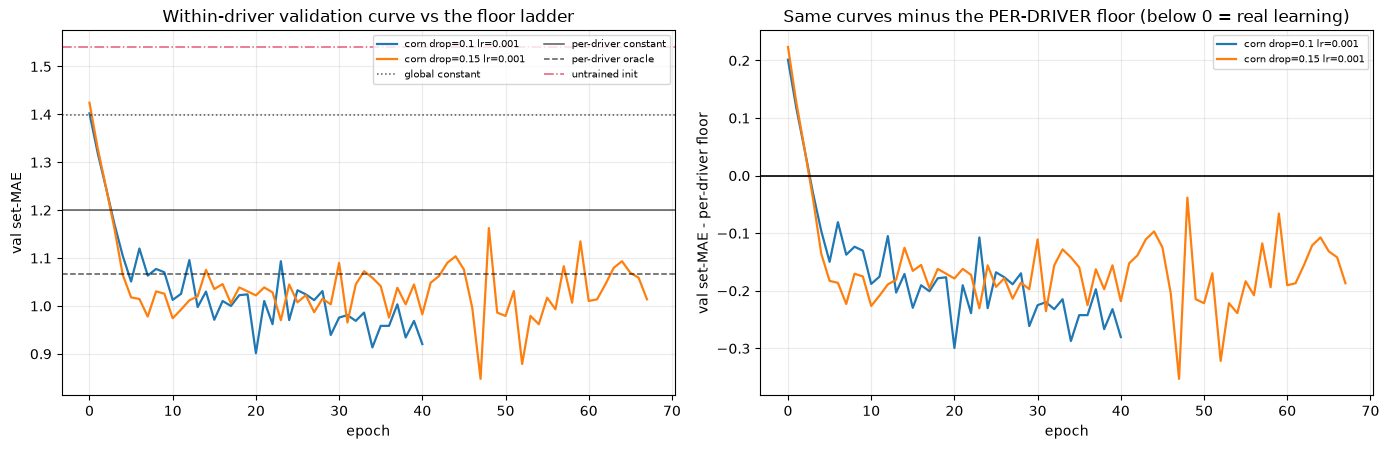


BEST ARM: corn drop=0.1 lr=0.001  set-MAE 0.955  (init 1.535, global floor 1.398, per-driver floor 1.201, QWK 0.492)

VERDICT: explanation (a). The features DO carry LoA signal and the
training path works - the model beats a floor that already knows who is
driving. Sections 1-4 are then a TRANSFER failure, not a learnability
failure, and the population checkpoint is legitimately an initialization
rather than a result. soft-CORN is not broken.


In [17]:
# --------------------------- within-driver: curves plot and the verdict

def wd_plot_curves(curves: pd.DataFrame, df: pd.DataFrame):
    """Validation set-MAE vs epoch, one line per (loss, config), floors overlaid.

    Left: raw set-MAE with all three floors and the untrained init drawn in, so
    the reader sees which references the curve actually crosses and in what
    order. Right: the same curves MINUS the per-driver floor, where zero is the
    only line that matters and crossing it is this section's whole question.
    """
    if curves.empty:
        print("(no curves yet)")
        return
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
    pdc = float(df["pdconst_set_mae"].mean()) if not df.empty else np.nan

    for (loss, drop, lr), c in curves.groupby(["loss", "dropout", "lr"]):
        m = c.groupby("epoch")["set_mae"].mean()
        lbl = f"{loss} drop={drop} lr={lr:g}"
        axes[0].plot(m.index, m.values, label=lbl, lw=1.6)
        if np.isfinite(pdc):
            axes[1].plot(m.index, m.values - pdc, label=lbl, lw=1.6)

    if not df.empty:
        for nm, col, st in (("global constant", "const_set_mae", ":"),
                            ("per-driver constant", "pdconst_set_mae", "-"),
                            ("per-driver oracle", "pdconst_oracle_set_mae", "--")):
            axes[0].axhline(float(df[col].mean()), ls=st, c="k", lw=1.1, alpha=.65,
                            label=nm)
        axes[0].axhline(float(df["init_set_mae"].mean()), ls="-.", c="crimson", lw=1.1,
                        alpha=.7, label="untrained init")
    axes[1].axhline(0.0, c="k", lw=1.2)

    axes[0].set_title("Within-driver validation curve vs the floor ladder")
    axes[1].set_title("Same curves minus the PER-DRIVER floor (below 0 = real learning)")
    for a in axes:
        a.set_xlabel("epoch")
        a.grid(alpha=.25)
    axes[0].set_ylabel("val set-MAE")
    axes[1].set_ylabel("val set-MAE - per-driver floor")
    axes[0].legend(fontsize=7, ncol=2)
    if np.isfinite(pdc):
        axes[1].legend(fontsize=7)
    plt.tight_layout()
    plt.show()


def wd_verdict(df: pd.DataFrame) -> None:
    """State which of explanation (a) or (b) the run supports, in words.

    Deliberately blunt: this section exists to make one decision, and leaving it
    implicit in a table is how a null result gets read as a positive one.
    """
    if df.empty:
        print("(no completed runs)")
        return
    t = wd_table_per_arm(df)
    best = t.iloc[0]
    learns = best["gain_vs_init"] > 0.01
    beats_pd = bool(best["beats_pdconst"])
    print(f"BEST ARM: {best['loss']} {best['config']}  set-MAE {best['set_mae']:.3f}"
          f"  (init {best['init_mae']:.3f}, global floor {best['const_mae']:.3f}, "
          f"per-driver floor {best['pdconst_mae']:.3f}, QWK {best['qwk']:.3f})")
    print()
    if learns and beats_pd:
        print("VERDICT: explanation (a). The features DO carry LoA signal and the")
        print("training path works - the model beats a floor that already knows who is")
        print("driving. Sections 1-4 are then a TRANSFER failure, not a learnability")
        print("failure, and the population checkpoint is legitimately an initialization")
        print("rather than a result. soft-CORN is not broken.")
    elif learns and not beats_pd:
        print("VERDICT: learned WHO, not WHEN. Training moves the model, but not past a")
        print("floor that needs no features at all - consistent with the embedding")
        print("carrying driver identity and little else. Run the bias-only adaptation")
        print("check before the LODO arms: if adapting only the CORN biases matches")
        print("adapting the full head, both arms are tied by construction.")
    else:
        print("VERDICT: explanation (b) is live. The model does not improve on its own")
        print("untrained init even with the driver in the training set. Suspect the")
        print("features or the training path BEFORE running either personalization arm.")
        print("Check soft_corn_loss against coral_pytorch on single-label rows first.")


_wd = wd_load()
if _wd.empty:
    print("(within-driver sweep has not produced results yet)")
else:
    display(Markdown("**Table 8 - per arm** (mean over seeds; read `vs_pdconst`, not `set_mae`)"))
    display(wd_table_per_arm(_wd))
    display(Markdown("**Table 9 - the floor ladder**"))
    display(wd_table_floors(_wd))
    display(Markdown("**Table 10 - CORN vs CE, paired on (dropout, lr, seed)**"))
    _wdp_tbl = wd_table_paired(_wd)
    display(_wdp_tbl if not _wdp_tbl.empty else "(needs both losses)")
    wd_plot_curves(wd_curves(), _wd)
    print()
    wd_verdict(_wd)

---
## 6. Cross-split contrast - what the two estimators say together

The number this analysis has been missing. Sections 1-4 measure a model on drivers it
has never seen; section 5 measures the same configurations on drivers it knows.
Neither is interesting alone:

* the cross-driver number alone cannot tell a transfer failure from an unlearnable
  task;
* the within-driver number alone is inflated by driver identity and is not a
  deployment estimate.

**Their gap is the quantity the personalization layer exists to recover.** Each side
is scored against *its own* binding floor - global constant for cross-driver, where an
unseen driver's favourite level is unknowable; per-driver constant for within-driver,
where it is free - so the two margins sit on comparable footing and their difference
is headroom rather than an artifact of whichever floor was handy.

**Read the headroom as an upper bound, generously drawn.** Part of it is genuine
per-driver preference structure that L2-SP and ANIL could recover; part is identity
memorization that a head adapted on K labels cannot reach; part is within-session
autocorrelation that neither arm will see at deployment. Two controls would tighten it
and are **not yet run** - state them as limitations rather than implying otherwise:

1. **Persistence baseline** - "repeat this driver's previous label". The natural floor
   for a temporal split, and stronger than the per-driver constant. If it matches the
   model, the within-driver result is autocorrelation, not learning.
2. **Random-backbone control** - the same probe on an untrained xLSTM's embeddings. An
   untrained recurrent net is a strong reservoir, and sections 1-4 already showed
   trained CORN scoring worse than its init, which is precisely that signature.

**Table 11 - cross-driver vs within-driver, same configurations**

,loss,config,n_cross,cross_mae,cross_floor,cross_vs_floor,n_within,within_mae,within_floor,within_vs_floor,headroom
0,corn,drop=0.1 lr=0.001,0,NaN,NaN,NaN,2,0.955,1.201,-0.246,NaN
1,corn,drop=0.15 lr=0.001,0,NaN,NaN,NaN,5,0.956,1.201,-0.245,NaN


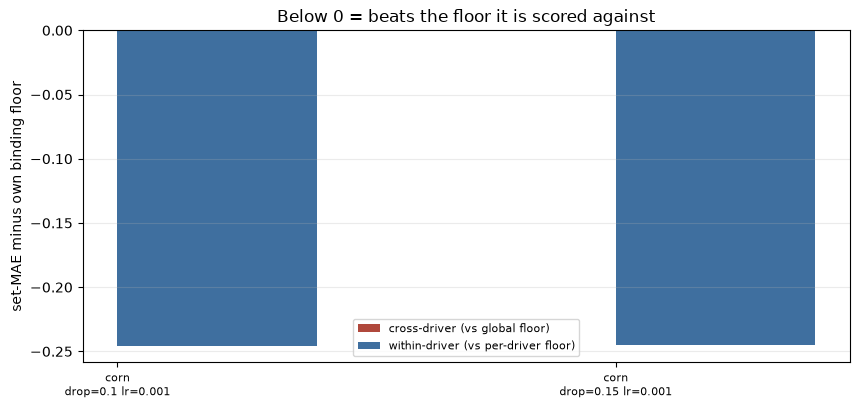

In [18]:
# ------------------------------------------ cross-split contrast table

def contrast_table(wd: pd.DataFrame) -> pd.DataFrame:
    """Cross-driver (sections 1-2) against within-driver (section 5), per arm.

    Matched on (loss, dropout, lr) and on the 10 s window, so the ONLY thing that
    differs between the two halves of a row is which drivers the validation
    segments came from.

    Each side is scored against its own binding floor - `*_vs_floor` - because a
    per-driver constant is free when the driver is in the training set and
    unknowable when they are not. `headroom` is the difference of those two
    margins: how much better the same configuration does once allowed to know
    the driver.
    """
    if wd.empty:
        return pd.DataFrame()
    stage_of = {"corn": "corn_w10", "ce": "ce_w10"}
    rows = []
    for (loss, drop, lr), g in wd.groupby(["loss", "dropout", "lr"]):
        cd = load_stage(stage_of.get(loss, ""))
        cd_mae = cd_floor = np.nan
        n_cd = 0
        if not cd.empty:
            sel = cd[np.isclose(cd["dropout"], drop) & np.isclose(cd["lr"], lr)]
            if not sel.empty:
                cd_mae = float(sel["smoothed_best_set_mae"].mean())
                cd_floor = float(sel["const_set_mae"].mean())
                n_cd = len(sel)
        wd_mae = float(g["smoothed_best_set_mae"].mean())
        wd_floor = float(g["pdconst_set_mae"].mean())
        rows.append({
            "loss": loss, "config": f"drop={drop} lr={lr:g}",
            "n_cross": n_cd, "cross_mae": cd_mae, "cross_floor": cd_floor,
            "cross_vs_floor": cd_mae - cd_floor,
            "n_within": len(g), "within_mae": wd_mae, "within_floor": wd_floor,
            "within_vs_floor": wd_mae - wd_floor,
            "headroom": (cd_mae - cd_floor) - (wd_mae - wd_floor),
        })
    t = pd.DataFrame(rows).sort_values("headroom", ascending=False).reset_index(drop=True)
    return _fmt(t, ["cross_mae", "cross_floor", "cross_vs_floor",
                    "within_mae", "within_floor", "within_vs_floor", "headroom"])


def contrast_plot(t: pd.DataFrame):
    """Margin against own floor, both splits, one bar pair per arm.

    Zero is the reference in both cases; bars below it beat their floor. The two
    splits share ONE axis precisely because the floors have already been
    subtracted - plotting raw set-MAE side by side would compare numbers that
    were never on the same scale.
    """
    if t.empty:
        print("(nothing to plot)")
        return
    lbl = (t["loss"] + "\n" + t["config"]).tolist()
    x = np.arange(len(t))
    fig, ax = plt.subplots(figsize=(1.9 * max(len(t), 3) + 3, 4.2))
    ax.bar(x - 0.2, t["cross_vs_floor"], 0.4, color="#b0483c",
           label="cross-driver (vs global floor)")
    ax.bar(x + 0.2, t["within_vs_floor"], 0.4, color="#3f6f9f",
           label="within-driver (vs per-driver floor)")
    ax.axhline(0, c="k", lw=1.2)
    ax.set_xticks(x)
    ax.set_xticklabels(lbl, fontsize=8)
    ax.set_ylabel("set-MAE minus own binding floor")
    ax.set_title("Below 0 = beats the floor it is scored against")
    ax.legend(fontsize=8)
    ax.grid(alpha=.25, axis="y")
    plt.tight_layout()
    plt.show()


if _wd.empty:
    print("(within-driver sweep has not produced results yet)")
else:
    _ct = contrast_table(_wd)
    display(Markdown("**Table 11 - cross-driver vs within-driver, same configurations**"))
    display(_ct)
    contrast_plot(_ct)
    if not _ct.empty and _ct["headroom"].notna().any():
        print(f"\nMax headroom across arms: {float(_ct['headroom'].max()):+.3f} set-MAE.")
        print("Upper bound on what personalization can recover on this cohort, before")
        print("the persistence and random-backbone controls above are subtracted.")